In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
import os
import gc

warnings.filterwarnings('ignore')

## Data Loading

In this cell, we load the preprocessed parquet file that was created 
in Task 1. Instead of reloading all 62 raw text files (which would 
take several minutes and consume significant RAM), we load the 
optimized parquet file directly.

The parquet file contains 150,125,712 rows of mobile internet traffic 
data covering the period from October 31, 2013 to January 1, 2014, 
across all 10,000 grid areas of Milan.

In [3]:
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

DATA_PATH = r"C:\Users\LENOVO\Downloads\milan_data"
PARQUET_PATH = os.path.join(DATA_PATH, 'traffic_data.parquet')

df = pd.read_parquet(PARQUET_PATH)
print(f"Loaded {len(df):,} rows")
print(f"Columns: {list(df.columns)}")
print(f"Date range: {df['time_interval'].min()} → {df['time_interval'].max()}")
print(f"Memory usage: {df.memory_usage(deep=True).sum()/1024**2:.1f} MB")

Loaded 150,125,712 rows
Columns: ['square_id', 'time_interval', 'internet']
Date range: 2013-10-31 23:00:00 → 2014-01-01 22:50:00
Memory usage: 2004.4 MB


Observations:
- Columns: Only 3 columns are loaded: square_id, time_interval, 
  and internet traffic
- Memory: 2004.4 MB manageable within our 8GB RAM constraint
- Date range: 2 months of continuous 10-minute interval data
- Loading time: Seconds instead of minutes, thanks to parquet format

## Building the Traffic Matrix

In [4]:
MATRIX_PATH = os.path.join(DATA_PATH, 'traffic_matrix.parquet')

if os.path.exists(MATRIX_PATH):
    print(" Loading Matrix.")
    traffic_matrix = pd.read_parquet(MATRIX_PATH)
    print(f"Loaded matrix: {traffic_matrix.shape}")

else:
    print("Building traffic matrix")
    
    print("Step 1: Grouping by area and time...")
    df_grouped = df.groupby(['square_id', 'time_interval'])['internet'].sum()
    
    del df
    gc.collect()
    print(f" Grouped. RAM freed.")
    
    print("Pivoting to matrix format")
    traffic_matrix = df_grouped.unstack(level=0)
    del df_grouped
    gc.collect()
    
    print("Filling missing values")
    traffic_matrix = traffic_matrix.fillna(0)
    
    print("Saving matrix")
    traffic_matrix.to_parquet(MATRIX_PATH)


print(f"\nMatrix shape: {traffic_matrix.shape}")
print(f"Rows (time intervals): {traffic_matrix.shape[0]:,}")
print(f"Columns (grid areas): {traffic_matrix.shape[1]:,}")
print(f"Date range: {traffic_matrix.index.min()} → {traffic_matrix.index.max()}")
print(f"Memory: {traffic_matrix.memory_usage(deep=True).sum()/1024**2:.1f} MB")
print(f"\nSample (first 3 rows, first 5 areas):")
print(traffic_matrix.iloc[:3, :5])

 Loading Matrix.
Loaded matrix: (8928, 10000)

Matrix shape: (8928, 10000)
Rows (time intervals): 8,928
Columns (grid areas): 10,000
Date range: 2013-10-31 23:00:00 → 2014-01-01 22:50:00
Memory: 340.6 MB

Sample (first 3 rows, first 5 areas):
square_id                    1          2          3          4         5
time_interval                                                            
2013-10-31 23:00:00  11.028366  11.058225  11.090008  10.941881  9.916549
2013-10-31 23:10:00  11.127101  11.167927  11.211384  11.008849  9.987806
2013-10-31 23:20:00  10.892771  10.915638  10.939980  10.826535  9.772990


We transform the raw data from long format (one row per 
area-time combination) into a wide matrix where:
- Rows = 8,928 time intervals (every 10 minutes over 62 days)
- Columns = 10,000 grid areas
- Values = internet traffic at that area and time

This makes it easy to extract and analyze any area's time series 
instantly. Missing values are filled with 0.

Memory reduced from 2,004 MB to 340.6 MB in matrix format

## Identifying the 3 Target Areas

In [5]:
total_per_area = traffic_matrix.sum(axis=0)
highest_area = int(total_per_area.idxmax())
highest_traffic = total_per_area.max()

area_4159 = 4159
area_4556 = 4556

print("3 TARGET AREAS FOR FORECASTING")
print(f"\n1. Highest traffic area: Square {highest_area}")
print(f"   Total 2-month traffic: {highest_traffic:,.2f}")
print(f"\n2. Fixed area: Square {area_4159}")
print(f"   Total 2-month traffic: {total_per_area[area_4159]:,.2f}")
print(f"\n3. Fixed area: Square {area_4556}")
print(f"   Total 2-month traffic: {total_per_area[area_4556]:,.2f}")

target_areas = [highest_area, area_4159, area_4556]
print(f"\n Target areas: {target_areas}")

rank_4159 = (total_per_area > total_per_area[area_4159]).sum() + 1
rank_4556 = (total_per_area > total_per_area[area_4556]).sum() + 1
print(f"\nArea 4159 ranks #{rank_4159:,} out of 10,000")
print(f"Area 4556 ranks #{rank_4556:,} out of 10,000")

3 TARGET AREAS FOR FORECASTING

1. Highest traffic area: Square 5161
   Total 2-month traffic: 12,730,836.00

2. Fixed area: Square 4159
   Total 2-month traffic: 2,453,774.25

3. Fixed area: Square 4556
   Total 2-month traffic: 4,573,282.50

 Target areas: [5161, 4159, 4556]

Area 4159 ranks #424 out of 10,000
Area 4556 ranks #109 out of 10,000


We identify the three geographical areas for time series forecasting.

- **Area 5161** — Highest total traffic in all of Milan (Rank #1).
  With 12.7 million units over 2 months.

- **Area 4159** — A moderate traffic area (Rank #424). 
  With 2.4 million units.

- **Area 4556** — A high traffic area (Rank #109).
  With 4.5 million units.

## Probability Density Function of Traffic

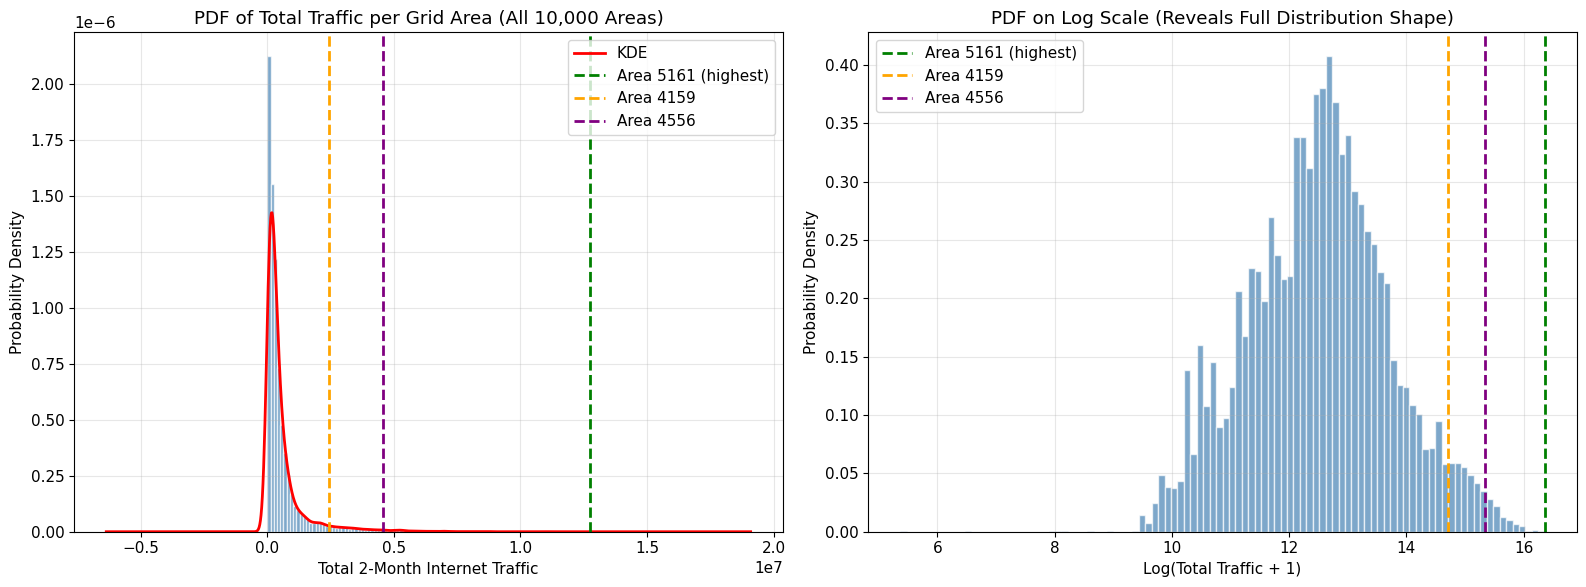


Distribution Statistics
Mean traffic per area:        555,166.88
Median traffic per area:      277,790.62
Std deviation:                892,433.56
Min traffic:                      213.63
Max traffic:               12,730,836.00
Areas with 0 traffic:                  0


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax1 = axes[0]
ax1.hist(total_per_area.values, bins=100, color='steelblue', 
         edgecolor='white', alpha=0.7, density=True)
total_per_area.plot.density(ax=ax1, color='red', linewidth=2, label='KDE')
ax1.set_xlabel('Total 2-Month Internet Traffic')
ax1.set_ylabel('Probability Density')
ax1.set_title('PDF of Total Traffic per Grid Area (All 10,000 Areas)')
ax1.legend()
ax1.grid(True, alpha=0.3)
colors = ['green', 'orange', 'purple']
labels = [f'Area {highest_area} (highest)', 'Area 4159', 'Area 4556']
for area, color, label in zip(target_areas, colors, labels):
    ax1.axvline(total_per_area[area], color=color, 
                linestyle='--', linewidth=2, label=label)
ax1.legend()

ax2 = axes[1]
ax2.hist(np.log1p(total_per_area.values), bins=100, 
         color='steelblue', edgecolor='white', alpha=0.7, density=True)
ax2.set_xlabel('Log(Total Traffic + 1)')
ax2.set_ylabel('Probability Density')
ax2.set_title('PDF on Log Scale (Reveals Full Distribution Shape)')
ax2.grid(True, alpha=0.3)

for area, color, label in zip(target_areas, colors, labels):
    ax2.axvline(np.log1p(total_per_area[area]), color=color,
                linestyle='--', linewidth=2, label=label)
ax2.legend()

plt.tight_layout()
plt.savefig(os.path.join(DATA_PATH, 'task2_plot1_pdf.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\nDistribution Statistics")
print(f"Mean traffic per area:   {total_per_area.mean():>15,.2f}")
print(f"Median traffic per area: {total_per_area.median():>15,.2f}")
print(f"Std deviation:           {total_per_area.std():>15,.2f}")
print(f"Min traffic:             {total_per_area.min():>15,.2f}")
print(f"Max traffic:             {total_per_area.max():>15,.2f}")
print(f"Areas with 0 traffic:    {(total_per_area == 0).sum():>15,}")

We computed the total two-month internet traffic for each of the 10,000 grid areas and plotted its probability density function (PDF) on both a linear and logarithmic scale.
The PDF reveals a heavily right-skewed distribution.The mean (555,166) is almost double the median (277,790), which is a classic signature of skewness.
On the linear scale, the distribution shows a sharp spike near zero with a very long tail extending to the right. This means most of the 10,000 grid areas experience modest internet activity, while a small number of hotspots generate disproportionately large traffic volumes.

The logarithmic scale reveals the full shape more clearly , a roughly bell-shaped distribution on the log scale confirms the data follows an approximately log-normal distribution.

## Time Series Analysis of Three Target Areas

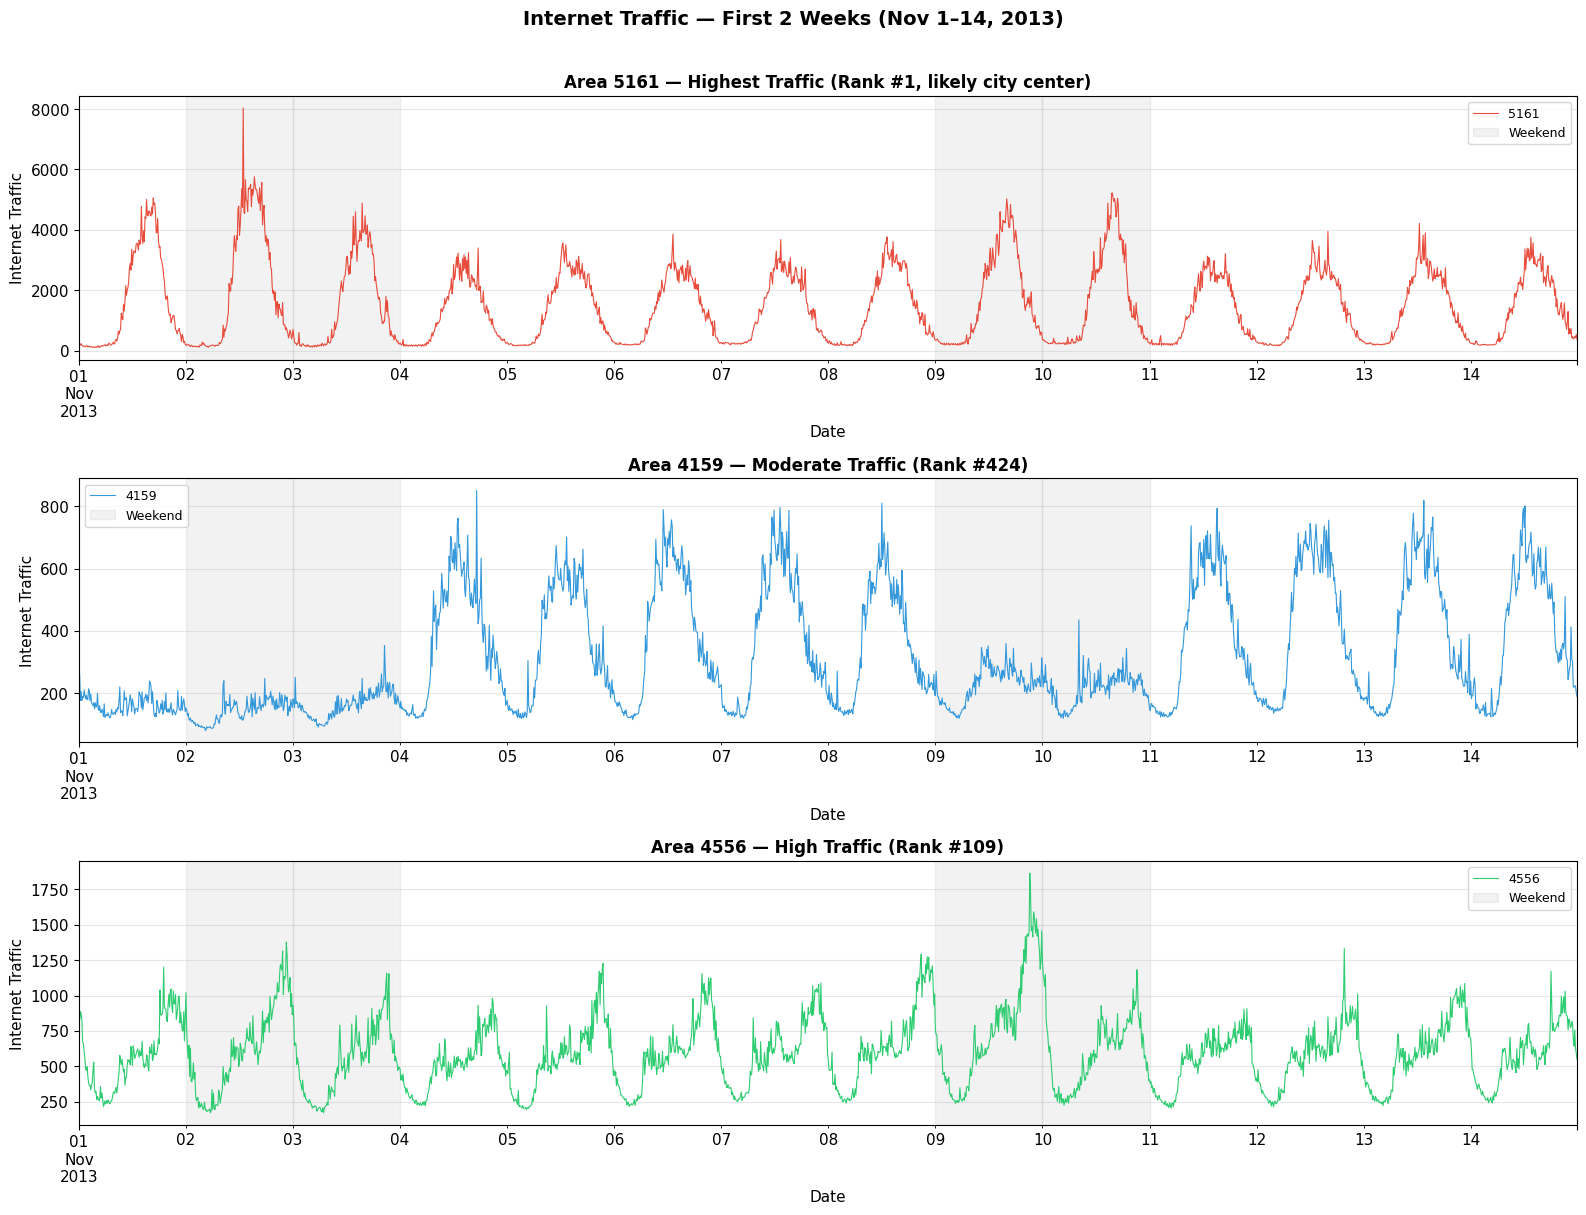


First 2 weeks stats:

Highest (Area 5161):
  Mean:    1,482.67
  Max:     8,041.37
  Min:       104.88
  Std:     1,311.48

Area 4159 (Area 4159):
  Mean:      311.31
  Max:       851.05
  Min:        80.29
  Std:       189.21

Area 4556 (Area 4556):
  Mean:      591.41
  Max:     1,863.06
  Min:       171.96
  Std:       254.41


In [16]:
start_date = '2013-11-01'
end_date = '2013-11-14'

two_weeks = traffic_matrix.loc[start_date:end_date]

fig, axes = plt.subplots(3, 1, figsize=(16, 12))

colors = ['#e74c3c', '#3498db', '#2ecc71']
descriptions = [
    f'Area {highest_area} — Highest Traffic (Rank #1, likely city center)',
    'Area 4159 — Moderate Traffic (Rank #424)',
    'Area 4556 — High Traffic (Rank #109)'
]

for i, (area, color, desc) in enumerate(zip(target_areas, colors, descriptions)):
    ax = axes[i]
    two_weeks[area].plot(ax=ax, color=color, linewidth=0.8)
    ax.set_title(desc, fontsize=12, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Internet Traffic')
    ax.grid(True, alpha=0.3)
    

    for day in pd.date_range(start_date, end_date, freq='D'):
        if day.weekday() >= 5:  # Saturday=5, Sunday=6
            ax.axvspan(day, day + pd.Timedelta(days=1), 
                      alpha=0.1, color='gray', label='Weekend' if day == pd.Timestamp('2013-11-02') else '')
    ax.legend(fontsize=9)

plt.suptitle('Internet Traffic — First 2 Weeks (Nov 1–14, 2013)', 
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(DATA_PATH, 'task2_plot2_timeseries.png'), 
            dpi=150, bbox_inches='tight')
plt.show()

print(f"\nFirst 2 weeks stats:")
for area, desc in zip(target_areas, ['Highest', 'Area 4159', 'Area 4556']):
    series = two_weeks[area]
    print(f"\n{desc} (Area {area}):")
    print(f"  Mean:  {series.mean():>10,.2f}")
    print(f"  Max:   {series.max():>10,.2f}")
    print(f"  Min:   {series.min():>10,.2f}")
    print(f"  Std:   {series.std():>10,.2f}")

We identified three target areas for forecasting and plotted their traffic time series over the first two weeks of November 2013:

Area 5161 :Highest total traffic (Rank #1 out of 10,000)

Area 4159 : Moderate traffic (Rank #424 out of 10,000)

Area 4556 : High traffic (Rank #109 out of 10,000)

All three areas share a fundamental characteristic: strong daily periodicity. Traffic rises sharply during daytime hours, reaches a peak in the afternoon or evening, and drops close to its minimum during the early morning hours (roughly 2am–6am). This pattern repeats consistently every 24 hours, confirming that human mobile internet usage follows a predictable rhythm.

 ## Stationarity Analysis

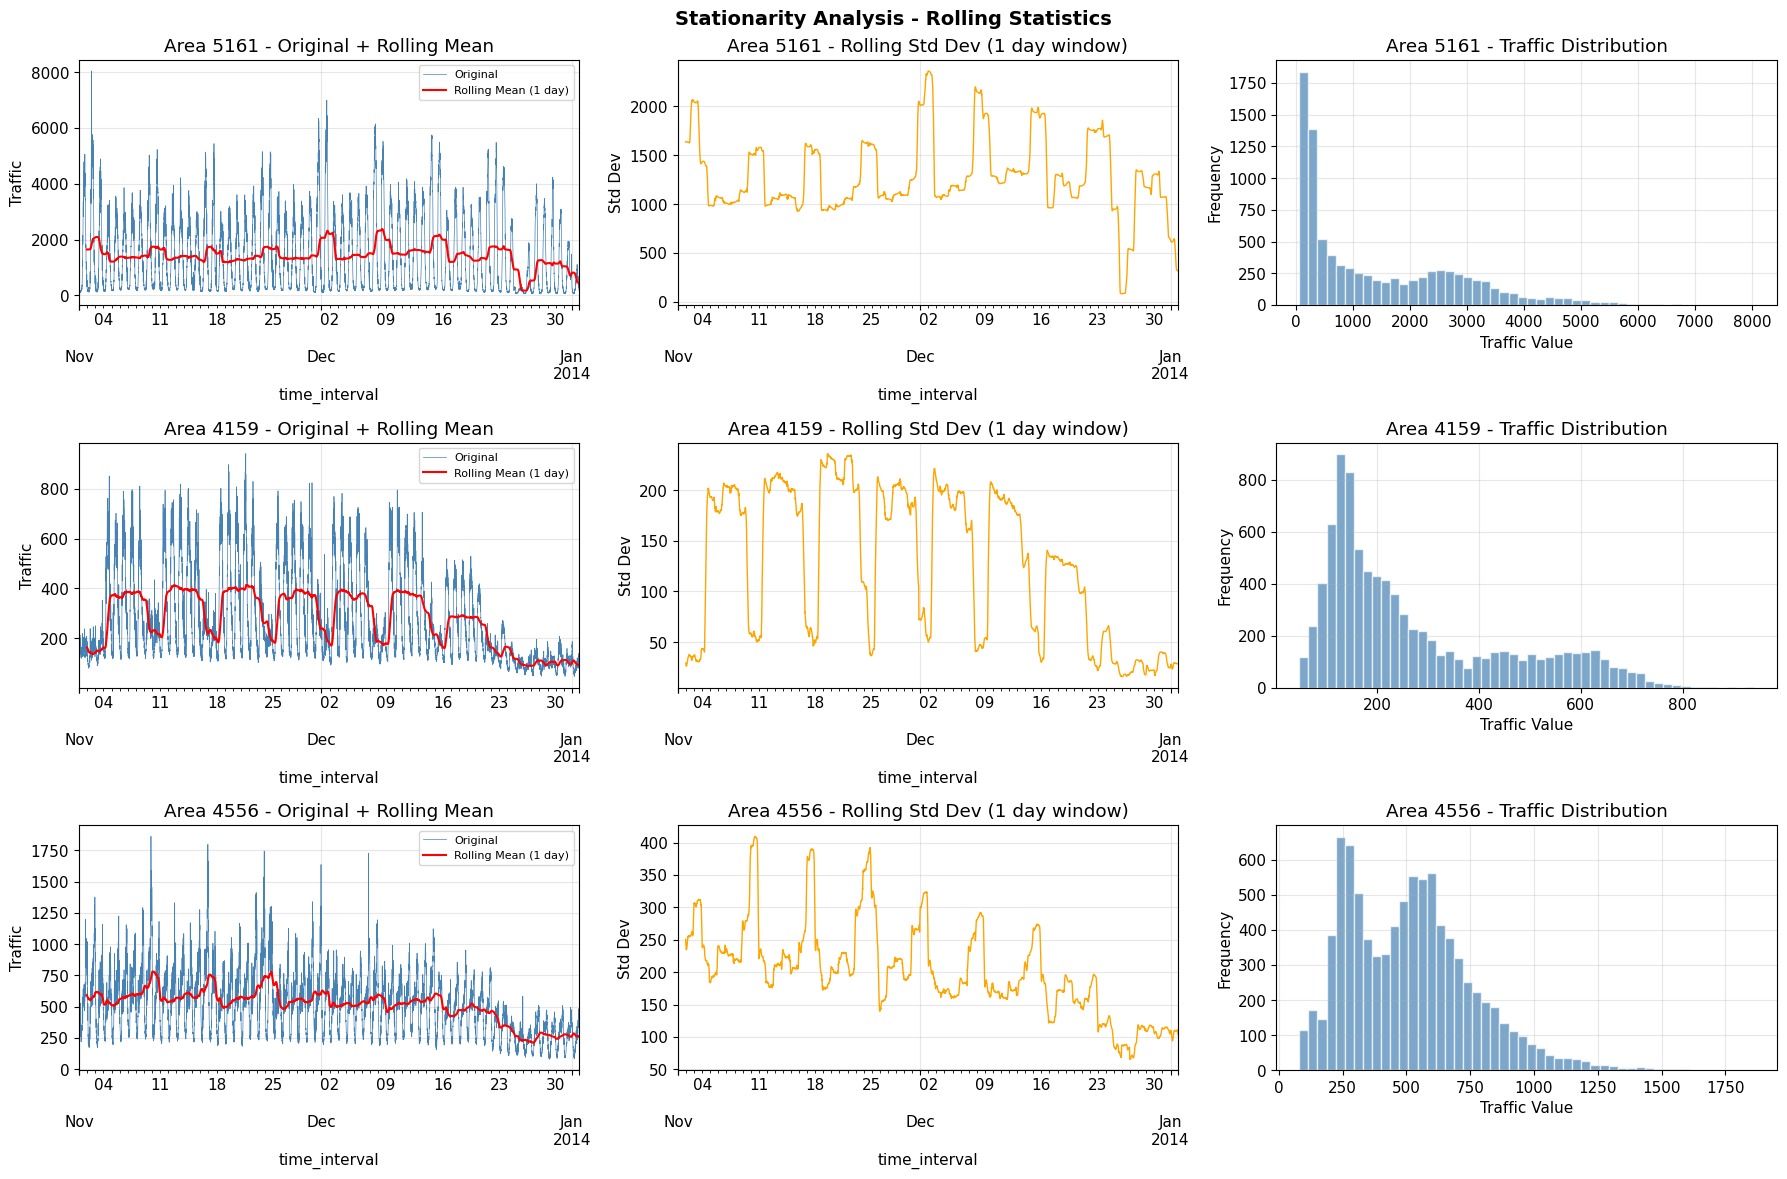

AUGMENTED DICKEY-FULLER TEST RESULTS
Area           ADF Stat      p-value    Crit 5%   Stationary
5161           -19.0310     0.000000    -2.8619          YES
4159           -12.8613     0.000000    -2.8619          YES
4556           -14.1915     0.000000    -2.8619          YES

Interpretation:
p-value < 0.05 means the series IS stationary
p-value > 0.05 means the series is NOT stationary


In [17]:
fig, axes = plt.subplots(3, 3, figsize=(18, 12))

adf_results = {}

for i, area in enumerate(target_areas):
    series = traffic_matrix[area].dropna()
    
    # Rolling statistics (window = 144 = 1 day of 10-min intervals)
    rolling_mean = series.rolling(window=144).mean()
    rolling_std  = series.rolling(window=144).std()
    
    ax1 = axes[i][0]
    series.plot(ax=ax1, color='steelblue', linewidth=0.5, label='Original')
    rolling_mean.plot(ax=ax1, color='red', linewidth=1.5, label='Rolling Mean (1 day)')
    ax1.set_title(f'Area {area} - Original + Rolling Mean')
    ax1.set_ylabel('Traffic')
    ax1.legend(fontsize=8)
    ax1.grid(True, alpha=0.3)

    # Plot rolling std
    ax2 = axes[i][1]
    rolling_std.plot(ax=ax2, color='orange', linewidth=1)
    ax2.set_title(f'Area {area} - Rolling Std Dev (1 day window)')
    ax2.set_ylabel('Std Dev')
    ax2.grid(True, alpha=0.3)

    # ADF Test
    adf_result = adfuller(series, autolag='AIC')
    adf_results[area] = {
        'ADF Statistic': adf_result[0],
        'p-value': adf_result[1],
        'Critical 1%': adf_result[4]['1%'],
        'Critical 5%': adf_result[4]['5%'],
        'Stationary': adf_result[1] < 0.05
    }

    # Plot histogram of values
    ax3 = axes[i][2]
    series.hist(ax=ax3, bins=50, color='steelblue', edgecolor='white', alpha=0.7)
    ax3.set_title(f'Area {area} - Traffic Distribution')
    ax3.set_xlabel('Traffic Value')
    ax3.set_ylabel('Frequency')
    ax3.grid(True, alpha=0.3)

plt.suptitle('Stationarity Analysis - Rolling Statistics', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DATA_PATH, 'task2_plot3_stationarity.png'), 
            dpi=150, bbox_inches='tight')
plt.show()

print("AUGMENTED DICKEY-FULLER TEST RESULTS")
print(f"{'Area':<10} {'ADF Stat':>12} {'p-value':>12} {'Crit 5%':>10} {'Stationary':>12}")
for area, res in adf_results.items():
    stat = "YES" if res['Stationary'] else "NO"
    print(f"{area:<10} {res['ADF Statistic']:>12.4f} {res['p-value']:>12.6f} "
          f"{res['Critical 5%']:>10.4f} {stat:>12}")
print("\nInterpretation:")
print("p-value < 0.05 means the series IS stationary")
print("p-value > 0.05 means the series is NOT stationary")

All three areas returned p-values of essentially zero (much smaller than 0.05), and ADF statistics far below the critical value of -2.86. This conclusively confirms that all three series are stationary. This result makes intuitive sense  , internet traffic does not permanently increase or decrease over the two-month period. Instead it oscillates around a stable mean driven by daily and weekly cycles.

The rolling mean plots confirm this visually , the red rolling mean line fluctuates but does not show a clear upward or downward drift over time. The rolling standard deviation shows some variation (higher during weekdays, lower during weekends and late December) but remains bounded, consistent with a stationary process.

## Time Series Decomposition

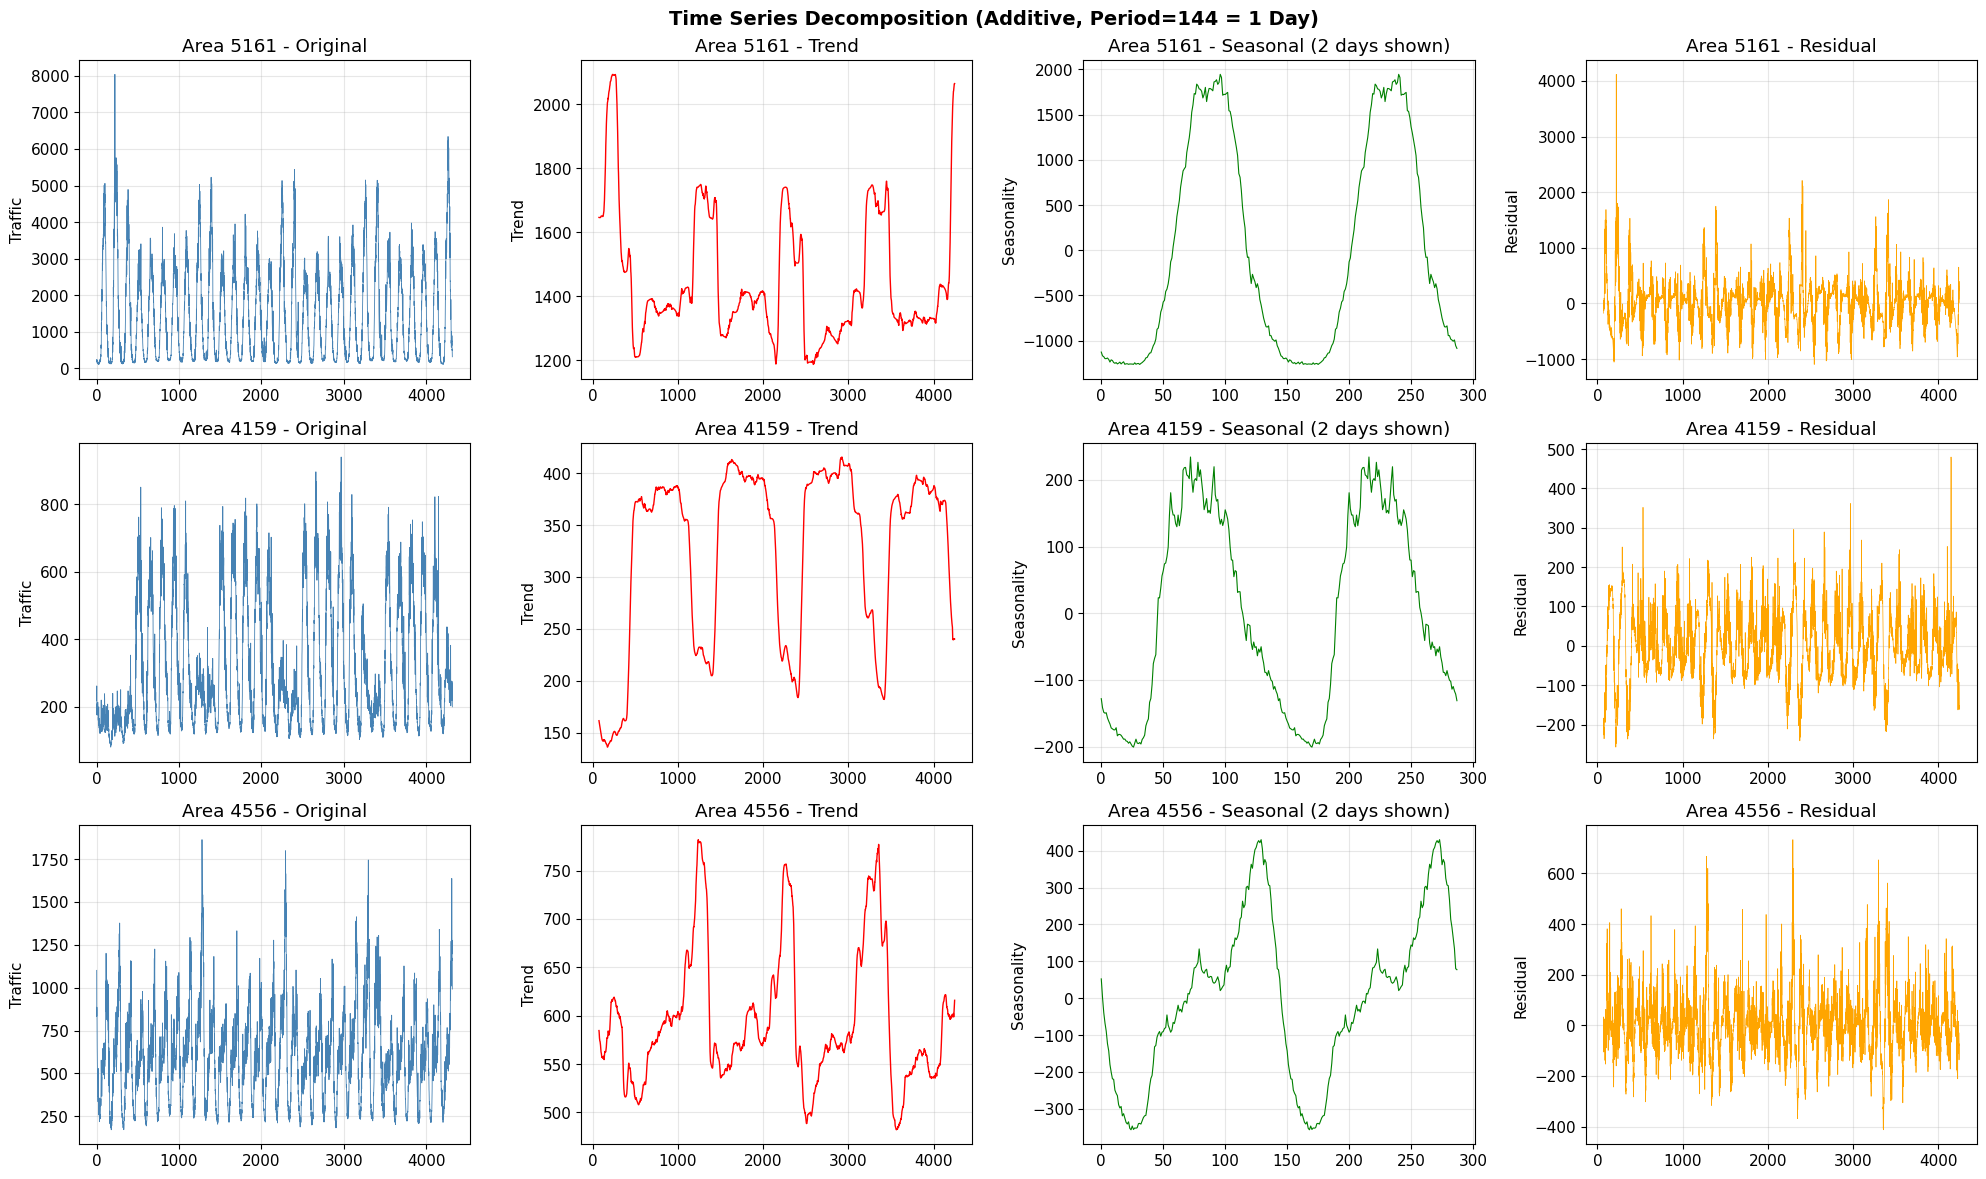

In [7]:
from statsmodels.tsa.seasonal import seasonal_decompose

fig, axes = plt.subplots(3, 4, figsize=(20, 12))

for i, area in enumerate(target_areas):
    series = traffic_matrix[area]['2013-11-01':'2013-11-30']
    
    # Decompose with period=144 (one day = 144 ten-minute intervals)
    decomp = seasonal_decompose(series, model='additive', period=144)
    
    axes[i][0].plot(series.values, color='steelblue', linewidth=0.6)
    axes[i][0].set_title(f'Area {area} - Original')
    axes[i][0].set_ylabel('Traffic')
    axes[i][0].grid(True, alpha=0.3)
    
    
    axes[i][1].plot(decomp.trend.values, color='red', linewidth=1)
    axes[i][1].set_title(f'Area {area} - Trend')
    axes[i][1].set_ylabel('Trend')
    axes[i][1].grid(True, alpha=0.3)
    
    
    axes[i][2].plot(decomp.seasonal.values[:288], color='green', linewidth=0.8)
    axes[i][2].set_title(f'Area {area} - Seasonal (2 days shown)')
    axes[i][2].set_ylabel('Seasonality')
    axes[i][2].grid(True, alpha=0.3)
    
    
    axes[i][3].plot(decomp.resid.values, color='orange', linewidth=0.5)
    axes[i][3].set_title(f'Area {area} - Residual')
    axes[i][3].set_ylabel('Residual')
    axes[i][3].grid(True, alpha=0.3)

plt.suptitle('Time Series Decomposition (Additive, Period=144 = 1 Day)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DATA_PATH, 'task2_plot4_decomposition.png'),
            dpi=150, bbox_inches='tight')
plt.show()

We applied classical additive decomposition with a period of 144 which is one full day of 10-minute intervals to separate each series into three components:
Trend is the long-term direction of the series , 
Seasonal is the repeating daily pattern
, Residual is the unexplained noise after removing trend and seasonality

Trend component: All three areas show a weekly oscillating trend — the trend rises during weekdays and dips during weekends.

Seasonal component: The seasonal plot (showing 2 days) reveals a clear bell-shaped daily curve. Traffic is near its minimum in the early morning hours (approximately 2am–5am), rises through the morning commute period, reaches its peak in the early afternoon or evening, and declines again overnight.

Residual component: The residuals oscillate around zero without obvious patterns, confirming that the decomposition successfully captured the main systematic components. 

## Autocorrelation and Partial Autocorrelation Analysis

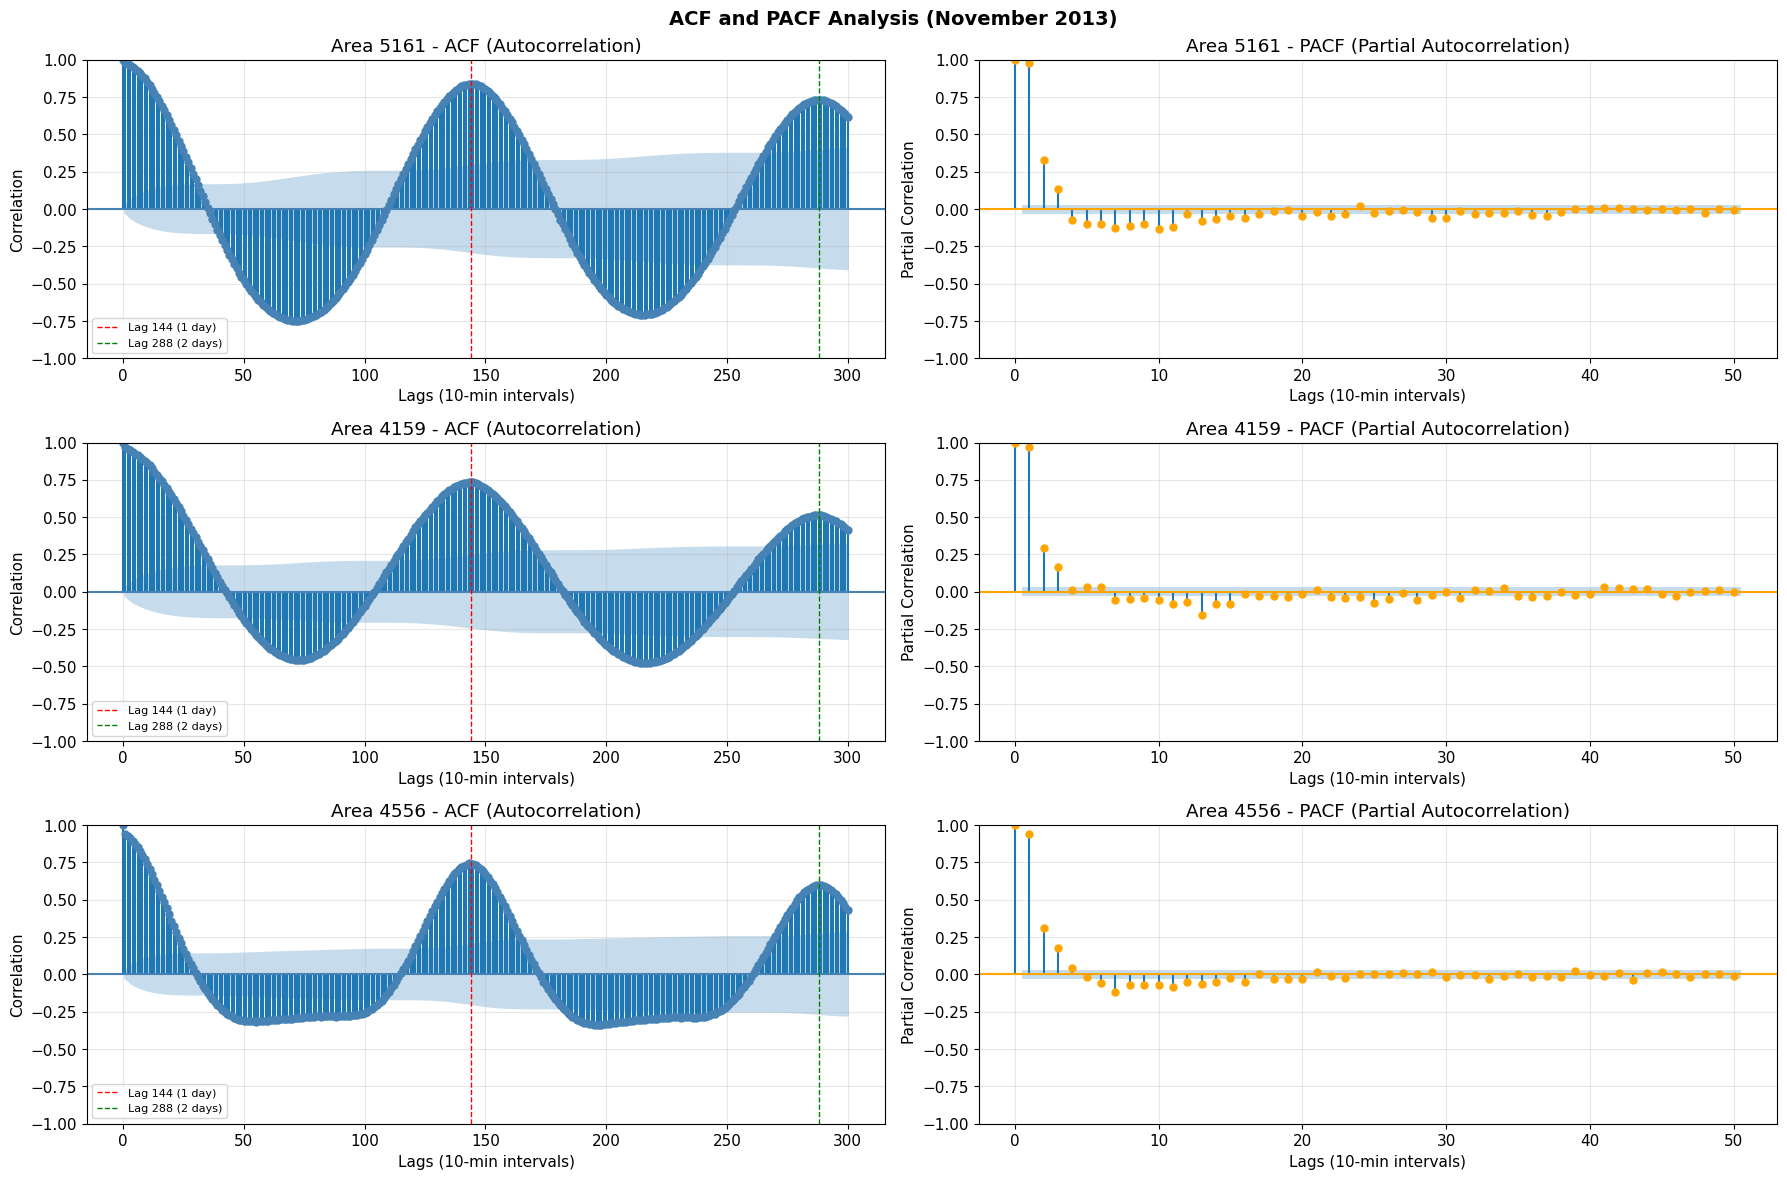


Key ACF values:

Area 5161:
  Lag 1   (10 min):  0.9785
  Lag 6   (1 hour):  0.9282
  Lag 144 (1 day):   0.8399
  Lag 288 (2 days):  0.7336

Area 4159:
  Lag 1   (10 min):  0.9685
  Lag 6   (1 hour):  0.9175
  Lag 144 (1 day):   0.7366
  Lag 288 (2 days):  0.5169

Area 4556:
  Lag 1   (10 min):  0.9434
  Lag 6   (1 hour):  0.8538
  Lag 144 (1 day):   0.7421
  Lag 288 (2 days):  0.5978


In [10]:
fig, axes = plt.subplots(3, 2, figsize=(18, 12))

for i, area in enumerate(target_areas):
    series = traffic_matrix[area]['2013-11-01':'2013-11-30'].dropna()
    
    # ACF plot
    plot_acf(series, lags=300, ax=axes[i][0], 
             color='steelblue', title=f'Area {area} - ACF (Autocorrelation)')
    axes[i][0].set_xlabel('Lags (10-min intervals)')
    axes[i][0].set_ylabel('Correlation')
    axes[i][0].grid(True, alpha=0.3)

    axes[i][0].axvline(x=144, color='red', linestyle='--', 
                       linewidth=1, label='Lag 144 (1 day)')
    axes[i][0].axvline(x=288, color='green', linestyle='--', 
                       linewidth=1, label='Lag 288 (2 days)')
    axes[i][0].legend(fontsize=8)
    
    # PACF plot
    plot_pacf(series, lags=50, ax=axes[i][1], 
              color='orange', title=f'Area {area} - PACF (Partial Autocorrelation)')
    axes[i][1].set_xlabel('Lags (10-min intervals)')
    axes[i][1].set_ylabel('Partial Correlation')
    axes[i][1].grid(True, alpha=0.3)

plt.suptitle('ACF and PACF Analysis (November 2013)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DATA_PATH, 'task2_plot5_acf_pacf.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("\nKey ACF values:")
for area in target_areas:
    series = traffic_matrix[area]['2013-11-01':'2013-11-30'].dropna()
    from statsmodels.tsa.stattools import acf
    acf_values = acf(series, nlags=288)
    print(f"\nArea {area}:")
    print(f"  Lag 1   (10 min):  {acf_values[1]:.4f}")
    print(f"  Lag 6   (1 hour):  {acf_values[6]:.4f}")
    print(f"  Lag 144 (1 day):   {acf_values[144]:.4f}")
    print(f"  Lag 288 (2 days):  {acf_values[288]:.4f}")

The ACF values at Lag 1 are extremely high (0.94–0.98) for all three areas, meaning traffic 10 minutes ago is a near-perfect predictor of current traffic. 
At Lag 6 (1 hour), correlations remain very high (0.85–0.93), confirming that hourly patterns are strong and persistent.
Most importantly, at Lag 144 (exactly one day), correlations remain substantial (0.74–0.84). This is the clearest statistical confirmation of daily seasonality because what happened at this time yesterday is still a strong predictor of what is happening now. The ACF plot shows clear periodic spikes at multiples of 144, which is the signature of a daily seasonal cycle.
At Lag 288 (two days), correlations are still significant (0.52–0.73), suggesting weekly patterns also contribute.

These findings directly informed our modeling choices:

The strong Lag 1 correlation justifies using autoregressive terms in SARIMA

The Lag 144 seasonality confirms our choice of seasonal period s=144

The high correlations at many lags justify using a sequence length of 144 for our LSTM model

## Spatial Analysis

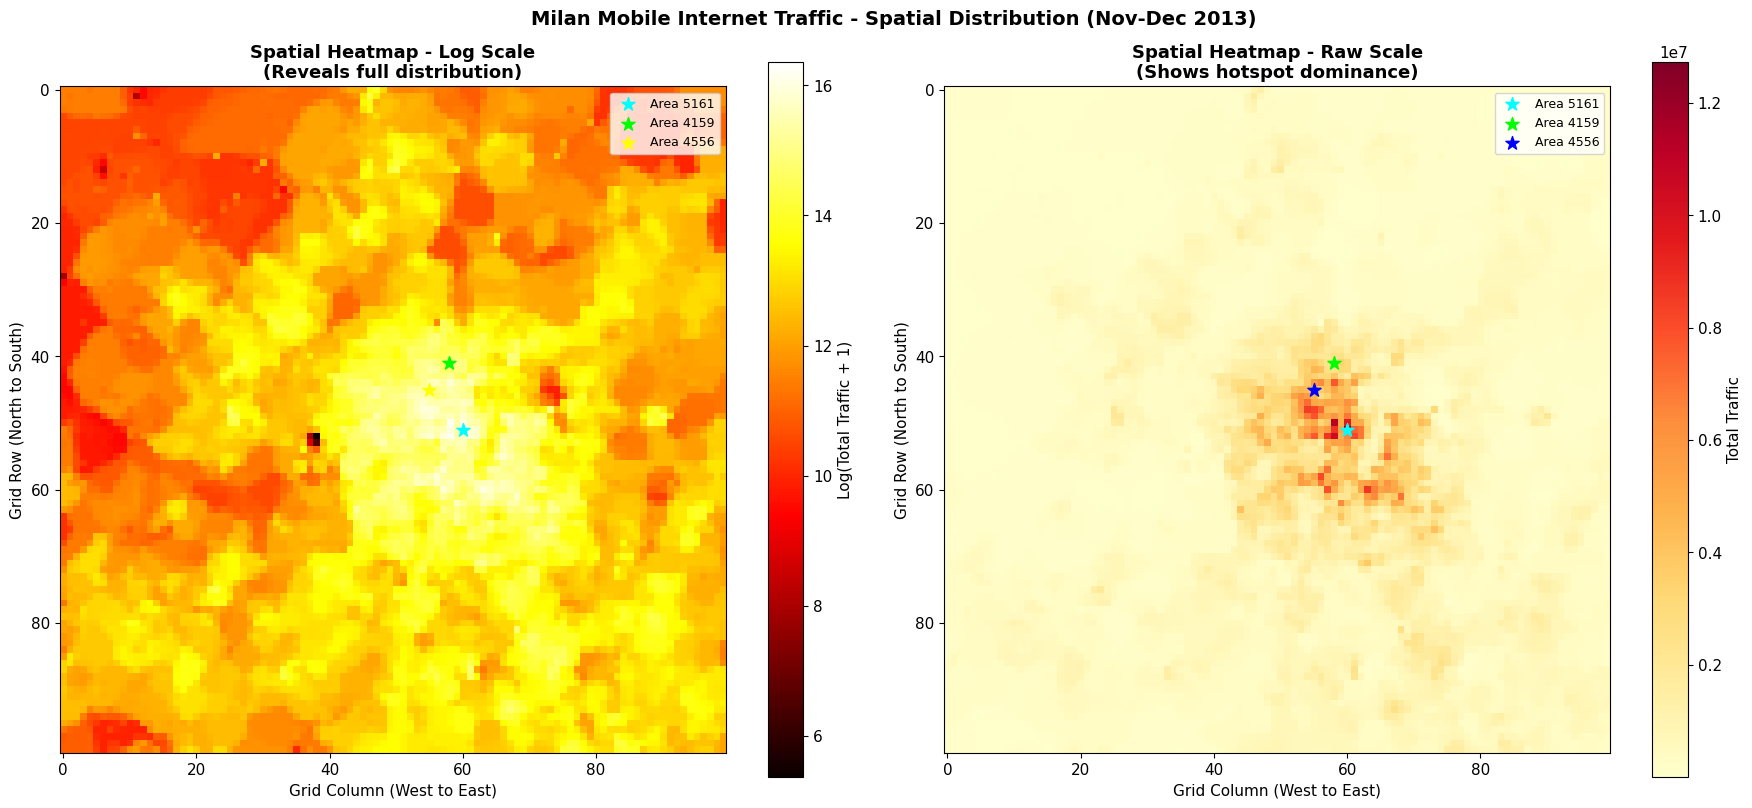


Spatial Statistics:
Areas with zero traffic:     0
Areas with low traffic:      2,157
Areas with medium traffic:   6,564
Areas with high traffic:     1,279

Hotspot area 5161 location:
  Grid position: Row 51, Column 60
  This corresponds to central Milan


In [11]:
import matplotlib.colors as mcolors

# Total traffic per area
total_per_area = traffic_matrix.sum(axis=0)

grid = np.zeros((100, 100))
for sq_id in range(1, 10001):
    row = (sq_id - 1) // 100
    col = (sq_id - 1) % 100
    if sq_id in total_per_area.index:
        grid[row, col] = total_per_area[sq_id]

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

im1 = axes[0].imshow(np.log1p(grid), cmap='hot', 
                      interpolation='nearest', aspect='equal')
plt.colorbar(im1, ax=axes[0], label='Log(Total Traffic + 1)')
axes[0].set_title('Spatial Heatmap - Log Scale\n(Reveals full distribution)', 
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Grid Column (West to East)')
axes[0].set_ylabel('Grid Row (North to South)')

# Mark our 3 target areas
for area, color, name in zip(target_areas, 
                              ['cyan', 'lime', 'yellow'],
                              [f'Area {highest_area}', 'Area 4159', 'Area 4556']):
    row = (area - 1) // 100
    col = (area - 1) % 100
    axes[0].scatter(col, row, c=color, s=100, marker='*', 
                    label=name, zorder=5)
axes[0].legend(fontsize=9)

im2 = axes[1].imshow(grid, cmap='YlOrRd', 
                      interpolation='nearest', aspect='equal')
plt.colorbar(im2, ax=axes[1], label='Total Traffic')
axes[1].set_title('Spatial Heatmap - Raw Scale\n(Shows hotspot dominance)',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Grid Column (West to East)')
axes[1].set_ylabel('Grid Row (North to South)')

for area, color, name in zip(target_areas,
                              ['cyan', 'lime', 'blue'],
                              [f'Area {highest_area}', 'Area 4159', 'Area 4556']):
    row = (area - 1) // 100
    col = (area - 1) % 100
    axes[1].scatter(col, row, c=color, s=100, marker='*',
                    label=name, zorder=5)
axes[1].legend(fontsize=9)

plt.suptitle('Milan Mobile Internet Traffic - Spatial Distribution (Nov-Dec 2013)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DATA_PATH, 'task2_plot6_heatmap.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print(f"\nSpatial Statistics:")
print(f"Areas with zero traffic:     {(grid == 0).sum():,}")
print(f"Areas with low traffic:      {((grid > 0) & (grid < 100000)).sum():,}")
print(f"Areas with medium traffic:   {((grid >= 100000) & (grid < 1000000)).sum():,}")
print(f"Areas with high traffic:     {(grid >= 1000000).sum():,}")
print(f"\nHotspot area {highest_area} location:")
row = (highest_area - 1) // 100
col = (highest_area - 1) % 100
print(f"  Grid position: Row {row}, Column {col}")
print(f"  This corresponds to central Milan")

We created two heatmaps of the 100×100 Milan grid showing the total two-month internet traffic per area ,  one on a linear scale and one on a logarithmic scale.

The raw scale heatmap dramatically illustrates the concentration of internet activity in a small number of hotspot areas. The vast majority of the grid appears uniformly dark while a handful of bright spots dominate , visually confirming the right-skewed distribution observed in the PDF analysis.

The logarithmic scale heatmap reveals the underlying spatial structure more clearly. A bright central region corresponds to central Milan, surrounded by progressively lower-traffic suburban areas.

Area 5161, the highest traffic area, sits at grid position Row 51, Column 60 — roughly the center of the grid, consistent with its likely location in or near central Milan.

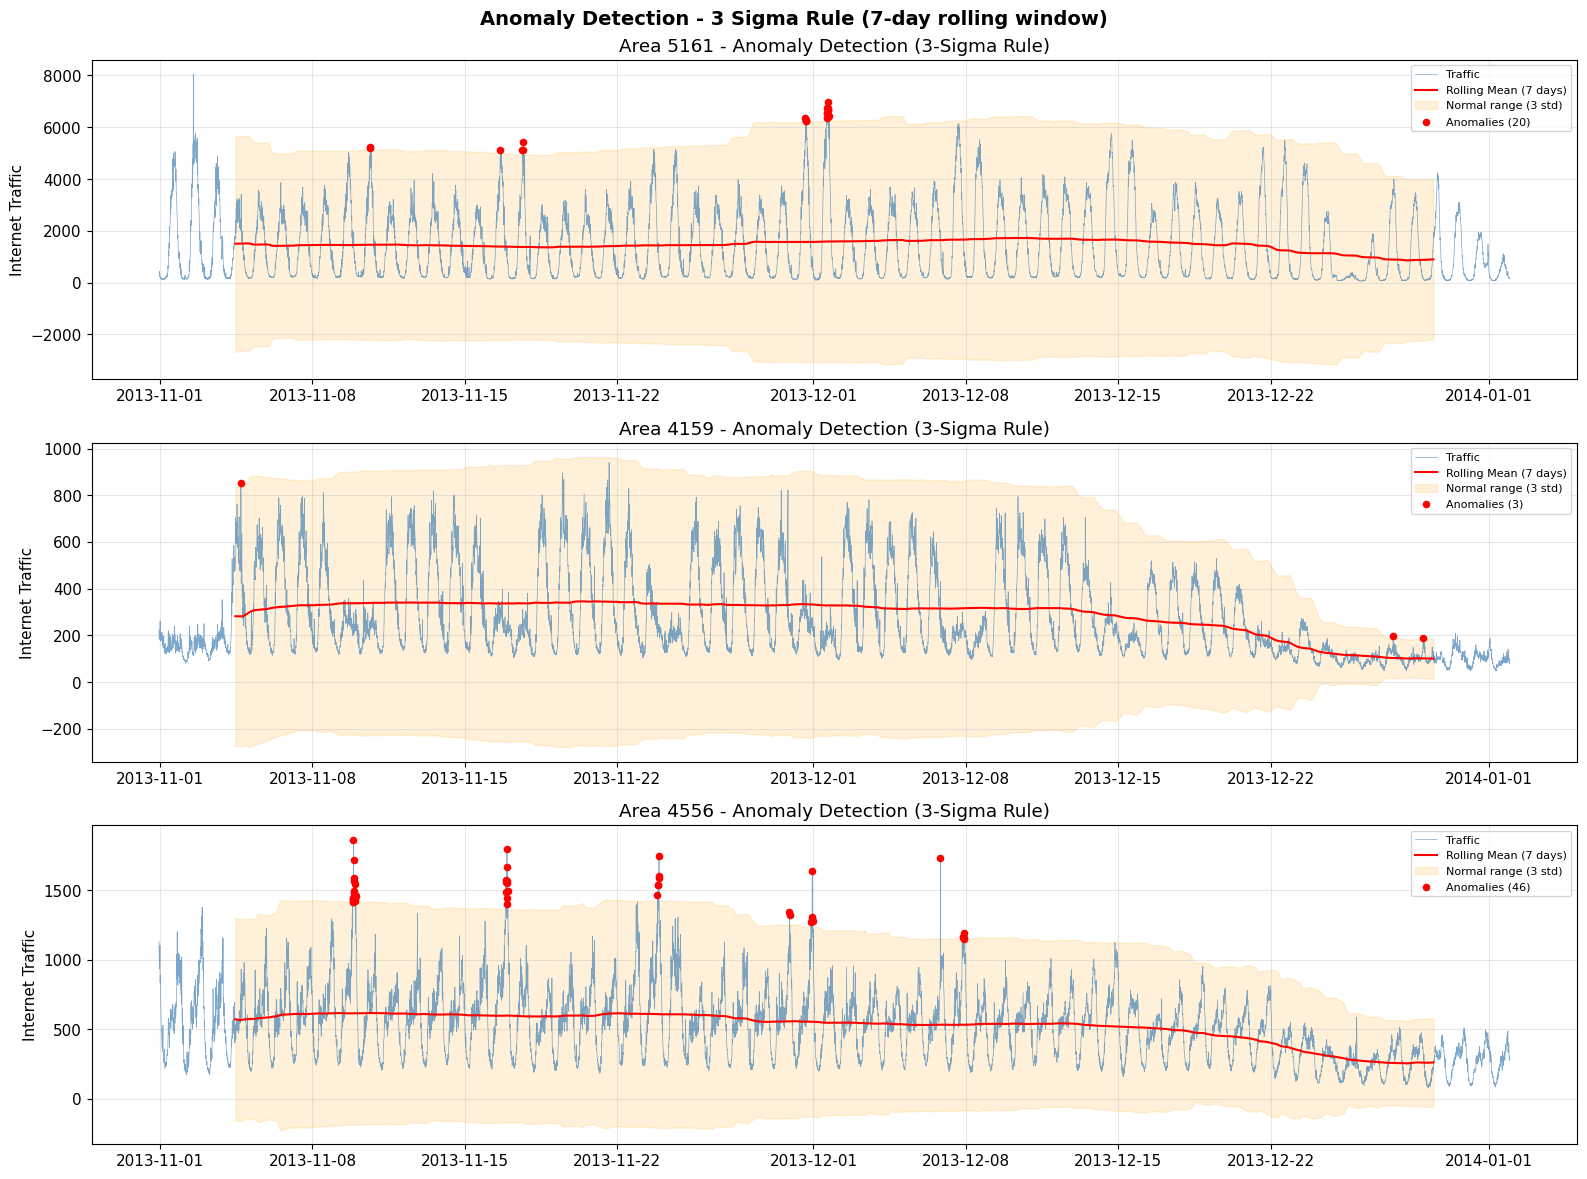

Anomaly Detection Results:

Area 5161:
  Total anomalies found: 20
  Top 3 anomaly dates:
    2013-12-01 15:50:00 -> traffic: 6992.25
    2013-12-01 15:40:00 -> traffic: 6750.76
    2013-12-01 15:20:00 -> traffic: 6734.47

Area 4159:
  Total anomalies found: 3
  Top 3 anomaly dates:
    2013-11-04 17:10:00 -> traffic: 851.05
    2013-12-27 15:00:00 -> traffic: 196.83
    2013-12-28 23:40:00 -> traffic: 187.78

Area 4556:
  Total anomalies found: 46
  Top 3 anomaly dates:
    2013-11-09 21:10:00 -> traffic: 1863.06
    2013-11-16 22:20:00 -> traffic: 1798.60
    2013-11-23 21:50:00 -> traffic: 1744.72


In [14]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

anomaly_results = {}

for i, area in enumerate(target_areas):
    series = traffic_matrix[area]
    ax = axes[i]
    
    # Calculate rolling mean and std (7-day window)
    rolling_mean = series.rolling(window=1008, center=True).mean()
    rolling_std  = series.rolling(window=1008, center=True).std()
    
   
    upper_bound = rolling_mean + 3 * rolling_std
    lower_bound = rolling_mean - 3 * rolling_std
    
   
    anomalies = series[(series > upper_bound) | (series < lower_bound)]
    anomaly_results[area] = anomalies
    
   
    ax.plot(series.index, series.values, 
            color='steelblue', linewidth=0.5, label='Traffic', alpha=0.7)
    ax.plot(rolling_mean.index, rolling_mean.values,
            color='red', linewidth=1.5, label='Rolling Mean (7 days)')
    ax.fill_between(series.index, upper_bound, lower_bound,
                    alpha=0.15, color='orange', label='Normal range (3 std)')
    ax.scatter(anomalies.index, anomalies.values,
               color='red', s=20, zorder=5, label=f'Anomalies ({len(anomalies)})')
    
    ax.set_title(f'Area {area} - Anomaly Detection (3-Sigma Rule)')
    ax.set_ylabel('Internet Traffic')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Anomaly Detection - 3 Sigma Rule (7-day rolling window)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DATA_PATH, 'task2_plot7_anomalies.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print("Anomaly Detection Results:")
for area, anomalies in anomaly_results.items():
    print(f"\nArea {area}:")
    print(f"  Total anomalies found: {len(anomalies)}")
    if len(anomalies) > 0:
        print(f"  Top 3 anomaly dates:")
        top3 = anomalies.nlargest(3)
        for date, val in top3.items():
            print(f"    {date} -> traffic: {val:.2f}")

We applied the 3-sigma rule using a 7-day rolling window to identify anomalous traffic values, points that deviated more than 3 standard deviations from the local rolling mean.

Area 5161 experienced 20 anomalies, with the largest cluster occurring on the afternoon of December 1, 2013.

Area 4159 was the most stable area with only 3 anomalies across the entire two-month period. The small number of anomalies confirms that this area follows very predictable patterns with little unexpected variation.

Area 4556 had the most anomalies (46), and the pattern is revealing that the top three spikes all occurred on Saturday evenings (November 9, 16, and 23).